# Disaster Classification : Socal-Fire VS Midwest-Flooding

This model utilizes satellite images from SoCal fires and Midwest flooding to classify the type of disaster. We decided to use a Gradient Boosted Classifier to handle fitting and predictions. It works well with tabular features, captures non-linear interactions, and provides feature importance, which helps interpret which metrics are most predictive. Gradient Boosting has several hyperparameters like `n_estimators`, `max_depth`, `learning_rate`, and `max_features`. These were tuned using cross-validation, aiming for a high macro F1 score while preventing overfitting.


Macro F1 was chosen because this metric treats both classes equally, balancing precision and recall rather than favoring one. Bias and variance were judged from cross-validation scores. The model showed low bias, as performance was consistent across folds. Overfitting was monitored by comparing training vs test fold scores and examining fold-wise confusion matrices. Feature importance was also inspected to ensure the model did not rely too heavily on a single feature.

In [ ]:
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score
from sklearn.ensemble import GradientBoostingClassifier
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
from skimage import color, feature, filters
from skimage.morphology import disk
from sklearn.metrics import roc_curve, roc_auc_score


The features were image-based metrics:
- LBP mean – captured local texture patterns. 
    - A low mean indicates disrupted textures, which can distinguish chaotic fire textures from smoother flood surfaces.
- Entropy mean – measured information content. 
    - High mean entropy corresponds to more complex patterns (fire), while low mean indicates more uniform areas (flood)
- Blue mean – captured the average blue intensity. 
    - Flooded images are likely to have higher blue intensity, while fire generally has less.
- Green mean – captured average green intensity. 
    - Flooded pictures tend to have higher green mean relative to fire images.


> Note: Features were extracted and saved as Npy files for easy loading.

In [2]:
lbp_mean = np.load("data/lbp_mean_classification.npy")
entropy_mean = np.load("data/entropy_mean_classification.npy")
blue = np.load("data/blue_classification.npy")
green = np.load("data/green_classification.npy")

features = ['lbp_mean', 'entropy_mean', 'blue', 'green']
X = np.concatenate([lbp_mean,  entropy_mean, blue, green], axis=1)
Y = np.load("data/classification_labels.npy")

label_legend = {
    0: "midwest-flooding",
    1: "socal-fire"
}

> Note: Here is the function used to extract features. It is not used in this notebook.

In [3]:
def extract_selected_features(images, save_path="data/", suffix="classification"):
    """
    Extracts selected features: lbp_mean, entropy_mean, blue, green
    and saves each as a separate .npy file in save_path.
    
    Parameters:
    - images: list or array of RGB images
    - save_path: folder to save .npy files
    - suffix: string to append at the end of each filename
    """
    import os

    os.makedirs(save_path, exist_ok=True)
    
    lbp_mean_list = []
    entropy_mean_list = []
    blue_list = []
    green_list = []
    
    for img in images:
        # Convert to grayscale for LBP and entropy
        img_gray = color.rgb2gray(img)
        
        # LBP
        lbp = feature.local_binary_pattern(img_gray, P=8, R=1, method="uniform")
        lbp_mean_list.append(np.mean(lbp))
        
        # Entropy
        img_gray_uint = (img_gray * 255).astype(np.uint8)
        entropy_img = filters.rank.entropy(img_gray_uint, disk(3))
        entropy_mean_list.append(np.mean(entropy_img))
        
        # Blue and Green channel means
        blue_list.append(np.mean(img[:,:,2]))
        green_list.append(np.mean(img[:,:,1]))
    
    np.save(save_path + f"lbp_mean_{suffix}.npy", np.array(lbp_mean_list).reshape(-1,1))
    np.save(save_path + f"entropy_mean_{suffix}.npy", np.array(entropy_mean_list).reshape(-1,1))
    np.save(save_path + f"blue_{suffix}.npy", np.array(blue_list).reshape(-1,1))
    np.save(save_path + f"green_{suffix}.npy", np.array(green_list).reshape(-1,1))

To test the robustness of the model, we used Stratified K-Fold Cross-Validation. The dataset is split into `n=5` folds, maintaining class distribution. For each fold, the model is trained on the training subset and evaluated on the untouched test subset. Fold-level metrics were averaged to produce the overall performance of the model.

In [4]:
def stratified_CV(X, Y, model, n_split=5, metric=accuracy_score):
    '''
    Performs stratified k-fold cross-validation,
    returns metrics and predictions.

    X: feature matrix
    Y: target labels
    model: scikit-learn classifier that has fit/predict/predict_proba
    n_split: number of folds (default 5)
    metric: scoring function, default accuracy_score

    Returns:
    mean_score: average metric across folds
    values: list of metric values per fold
    sum_cm: confusion matrix summed over all folds
    Y_true: concatenated true labels from all folds
    Y_prob: concatenated predicted probabilities from all folds
    '''

    skf = StratifiedKFold(n_splits=n_split, shuffle=True, random_state=42)
    
    values = []
    cms = []
    all_probs = []
    all_y_test = []

    for train_index, test_index in skf.split(X, Y): #run each train test on different splits of data
        print("Running Kfold...")
        X_train, X_test = X[train_index], X[test_index]
        Y_train, Y_test = Y[train_index], Y[test_index]

        model.fit(X_train, Y_train)
        Y_pred = model.predict(X_test)
        

        #gather additional data for graphs and metrics
        values.append(metric(Y_test, Y_pred, average="macro"))
        cms.append(confusion_matrix(Y_test, Y_pred))

        Y_prob = model.predict_proba(X_test)
        all_probs.append(Y_prob)
        all_y_test.append(Y_test)
        
    Y_prob = np.concatenate(all_probs)
    Y_true = np.concatenate(all_y_test)
    sum_cm = np.sum(np.stack(cms), axis=0)

    return np.mean(values), values, sum_cm, Y_true, Y_prob


In [8]:
def run_model(X, Y, n):
    
    model = GradientBoostingClassifier(n_estimators=100,learning_rate=0.8,max_depth=3)
    mean_score, values, matrix, Y_true, Y_prob = stratified_CV(X, Y, model, n_split= n, metric=f1_score)


    print(f"\nK1 Score = {mean_score}")
    print(f"K1 Values = {values}")


    '''
    Create Confusion Matrix
    '''
    labels = [label_legend[y] for y in np.unique(Y)]
    disp = ConfusionMatrixDisplay(confusion_matrix=matrix, display_labels=labels)
    disp.plot(cmap="Oranges", values_format='d', xticks_rotation= 45)
    plt.title("Disaster Types: Confusion Matrix for All Folds Summed")
    plt.tight_layout()
    plt.savefig("figures/classification_confusion_matrix.png", format="png")
    plt.close()

    '''
    Create Per-Fold F1 Scores Figure
    '''
    plt.plot(np.arange(1, n+1), values, marker='o', color= 'darkorange')
    plt.xlabel("Fold")
    plt.ylabel("Macro F1 Score")
    plt.title("Disaster Types: Per-Fold F1 Scores")
    plt.ylim(0,1)
    plt.xticks(np.arange(1, n+1))
    plt.savefig("figures/classification_KFold.png", format="png")
    plt.close()

    '''
    Create Importances Figure
    '''
    importances = model.feature_importances_
    plt.figure(figsize=(10,6))
    plt.bar(range(len(importances)), importances, color="darkorange")
    plt.xticks(range(len(importances)), features)
    plt.ylabel("Feature Importance")
    plt.ylabel("Feature Type")
    plt.title("Disaster Types: Gradient Boosted Tree Feature Importances")
    plt.savefig("figures/classification_importances.png", format="png")
    plt.close()


    '''
    Create ROC Curve
    '''
    fpr, tpr, thresholds = roc_curve(Y_true, Y_prob[:,1])
    auc = roc_auc_score(Y_true, Y_prob[:,1])

    plt.figure(figsize=(6,6))
    plt.plot(fpr, tpr, color='orange', lw=2, label=f'ROC curve (AUC = {auc:.2f})')
    plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  # random guess line
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.legend(loc="lower right")
    plt.xlabel("FPR")
    plt.ylabel("TPR")
    plt.legend()
    plt.title("Disaster Classification: ROC Curve per Disaster Label")
    plt.tight_layout()
    plt.savefig("figures/classification_ROC2.png", format="png")
    plt.close()

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best params (GB): {'learning_rate': 0.8, 'max_depth': 3, 'n_estimators': 100}
Best CV Weighted F1 (GB): 0.9374587643539257
Gradient Boosting - Validation Performance
Accuracy: 0.9625
Macro F1: 0.9624941397093296
Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.97      0.96        40
           1       0.97      0.95      0.96        40

    accuracy                           0.96        80
   macro avg       0.96      0.96      0.96        80
weighted avg       0.96      0.96      0.96        80



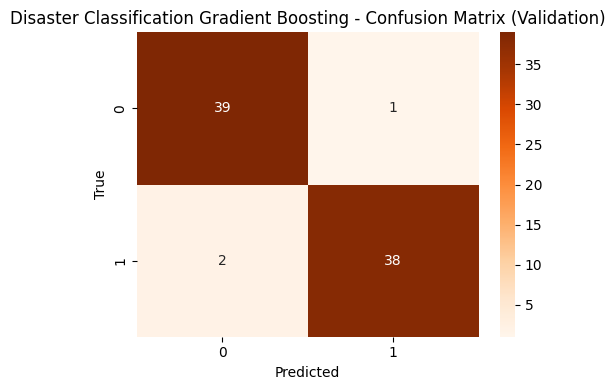

In [9]:
from sklearn.metrics import accuracy_score, classification_report, f1_score
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV

X_train, X_valid, Y_train, Y_valid = train_test_split(X, Y,test_size=0.2, stratify=Y, random_state=42)
def evaluate_on_validation(name, model, X_valid, Y_valid):
    """
    Print accuracy, macro F1, classification report, and show confusion matrix for a trained model evaluated on the validation set.
    """
    valid_preds = model.predict(X_valid)

    acc = accuracy_score(Y_valid, valid_preds)
    f1 = f1_score(Y_valid, valid_preds, average="macro")

    print(f"{name} - Validation Performance")
    print("Accuracy:", acc)
    print("Macro F1:", f1)
    print("Classification Report:")
    print(classification_report(Y_valid, valid_preds))

    cm = confusion_matrix(Y_valid, valid_preds)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Oranges")
    plt.title(f"Disaster Classification {name} - Confusion Matrix (Validation)")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.savefig("figures/classification_GB_validation.png")

    return acc, f1

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
gb = GradientBoostingClassifier(random_state=42)

gb_param_grid = {"n_estimators": [100, 200, 300],"learning_rate": [0.2, 0.5, 0.8],"max_depth": [1, 2, 3, 5]} #options to cycle through 

gb_grid = GridSearchCV(
    estimator=gb,
    param_grid=gb_param_grid,
    cv=cv,
    scoring="f1_macro",
    n_jobs=-1,
    verbose=1
)

gb_grid.fit(X_train, Y_train)

print("Best params (GB):", gb_grid.best_params_)
print("Best CV Weighted F1 (GB):", gb_grid.best_score_)

best_gb = gb_grid.best_estimator_
gb_val_acc, gb_val_f1 = evaluate_on_validation(
    "Gradient Boosting",
    best_gb,
    X_valid,
    Y_valid
)

In [12]:
run_model(X,Y, 5)

Running Kfold...
Running Kfold...
Running Kfold...
Running Kfold...
Running Kfold...

K1 Score = 0.9524925754991619
K1 Values = [0.9749843652282677, 0.9374902328488826, 0.925, 0.9874980465697765, 0.9374902328488826]


![ROC2](figures/classification_ROC2.png)

![CM](figures/classification_confusion_matrix.png)

![KFOLD](figures/classification_KFold.png)

![Imp](figures/classification_importances.png)

The model’s difficulty stemmed from subtle differences between classes in some images. Misclassification often occurred when color and texture cues could have been ambiguous, like charred areas vs water shadows.
To improve performance, we may want to add more discriminative features, like certain color ratios (R/B, R/G),  or try applying more filters to the images. Dimensionality reduction from PCA or other boosting methods like XGBoost could also be explored to increase classification accuracy. However, the K1 of this model is already very high. More refinement may lead to overfitting of the test set.
